In [ ]:
import pandas as pd

df = pd.read_excel("Online_Retail.xlsx")

print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [3]:
df.shape

(541909, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
print(df.describe())

            Quantity                 InvoiceDate      UnitPrice     CustomerID
count  541909.000000                      541909  541909.000000  406829.000000
mean        9.552250  2011-07-04 13:34:57.156386       4.611114   15287.690570
min    -80995.000000         2010-12-01 08:26:00  -11062.060000   12346.000000
25%         1.000000         2011-03-28 11:34:00       1.250000   13953.000000
50%         3.000000         2011-07-19 17:17:00       2.080000   15152.000000
75%        10.000000         2011-10-19 11:27:00       4.130000   16791.000000
max     80995.000000         2011-12-09 12:50:00   38970.000000   18287.000000
std       218.081158                         NaN      96.759853    1713.600303


In [7]:
print(df.loc[df["Quantity"].idxmax()])
print()
print(df.loc[df["UnitPrice"].idxmax()])

InvoiceNo                           581483
StockCode                            23843
Description    PAPER CRAFT , LITTLE BIRDIE
Quantity                             80995
InvoiceDate            2011-12-09 09:15:00
UnitPrice                             2.08
CustomerID                         16446.0
Country                     United Kingdom
Name: 540421, dtype: object

InvoiceNo                  C556445
StockCode                        M
Description                 Manual
Quantity                        -1
InvoiceDate    2011-06-10 15:31:00
UnitPrice                  38970.0
CustomerID                 15098.0
Country             United Kingdom
Name: 222681, dtype: object


In [8]:
df.duplicated().sum()

np.int64(5268)

In [9]:
df_copy = df.copy()

In [10]:
df_copy = df_copy.dropna(subset = ["CustomerID"])
df_copy = df_copy.drop_duplicates()
df_copy = df_copy[df_copy["UnitPrice"] > 0]

In [11]:
print(df_copy.shape)


(401564, 8)


In [12]:
print(df_copy.isnull().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [14]:
df_copy["TotalPrice"] = df_copy["Quantity"] * df_copy["UnitPrice"]

In [15]:
print(df_copy[["Quantity", "UnitPrice", "TotalPrice"]].describe())

            Quantity      UnitPrice     TotalPrice
count  401564.000000  401564.000000  401564.000000
mean       12.149911       3.474410      20.615691
std       249.512649      69.767501     430.373603
min    -80995.000000       0.001000 -168469.600000
25%         2.000000       1.250000       4.250000
50%         5.000000       1.950000      11.700000
75%        12.000000       3.750000      19.800000
max     80995.000000   38970.000000  168469.600000


In [16]:
df_copy[["CustomerID", "Quantity", "UnitPrice", "TotalPrice"]].head()

,CustomerID,Quantity,UnitPrice,TotalPrice
0,17850.0,6,2.55,15.30
1,17850.0,6,3.39,20.34
2,17850.0,8,2.75,22.00
3,17850.0,6,3.39,20.34
4,17850.0,6,3.39,20.34


In [17]:
monetary = df_copy.groupby("CustomerID")["TotalPrice"].sum()
print(monetary)

CustomerID
12346.0       0.00
12347.0    4310.00
12348.0    1797.24
12349.0    1757.55
12350.0     334.40
            ...   
18280.0     180.60
18281.0      80.82
18282.0     176.60
18283.0    2045.53
18287.0    1837.28
Name: TotalPrice, Length: 4371, dtype: float64


In [18]:
df_sales = df_copy[~df_copy["InvoiceNo"].astype(str).str.startswith("C")].copy()
df_sales.shape

(392692, 9)

In [19]:
frequency = df_sales.groupby("CustomerID")["InvoiceNo"].nunique()
print(frequency)

CustomerID
12346.0     1
12347.0     7
12348.0     4
12349.0     1
12350.0     1
           ..
18280.0     1
18281.0     1
18282.0     2
18283.0    16
18287.0     3
Name: InvoiceNo, Length: 4338, dtype: int64


In [20]:
df_sales["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [21]:
reference_date = df_sales["InvoiceDate"].max() + pd.Timedelta(days=1)
last_purchase = df_sales.groupby("CustomerID")["InvoiceDate"].max()
recency = (reference_date - last_purchase).dt.days

print(recency)

CustomerID
12346.0    326
12347.0      2
12348.0     75
12349.0     19
12350.0    310
          ... 
18280.0    278
18281.0    181
18282.0      8
18283.0      4
18287.0     43
Name: InvoiceDate, Length: 4338, dtype: int64


In [22]:
rfm = pd.concat([recency, frequency, monetary], axis=1, join="inner")
rfm.columns = ["Recency", "Frequency", "Monetary"]
print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1      0.00
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


In [23]:
print(rfm.shape)
print(rfm.isnull().sum())


(4338, 3)
Recency      0
Frequency    0
Monetary     0
dtype: int64


In [24]:
print(rfm.describe())

           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    1910.772398
std     100.014169     7.697998    8248.237548
min       1.000000     1.000000   -1165.300000
25%      18.000000     1.000000     298.027500
50%      51.000000     2.000000     649.955000
75%     142.000000     5.000000    1620.705000
max     374.000000   209.000000  279489.020000


In [25]:
print((rfm["Monetary"] <= 0).sum())

16


In [26]:
print(rfm.sort_values("Frequency", ascending=False).head(10))

            Recency  Frequency   Monetary
CustomerID                               
12748.0           1        209   28405.56
14911.0           1        201  132458.73
17841.0           2        124   39869.05
13089.0           3         97   57322.13
14606.0           1         93   11633.35
15311.0           1         91   59284.19
12971.0           4         86   10930.26
14646.0           2         73  279489.02
16029.0          39         63   53168.69
13408.0           2         62   27487.41


In [27]:
print(rfm.sort_values("Monetary", ascending=False).head(10))

            Recency  Frequency   Monetary
CustomerID                               
14646.0           2         73  279489.02
18102.0           1         60  256438.49
17450.0           8         46  187322.17
14911.0           1        201  132458.73
12415.0          24         21  123725.45
14156.0          10         55  113214.59
17511.0           3         31   88125.38
16684.0           4         28   65892.08
13694.0           4         50   62690.54
15311.0           1         91   59284.19


In [28]:
rfm = rfm[rfm["Monetary"] > 0]
rfm.shape

(4322, 3)

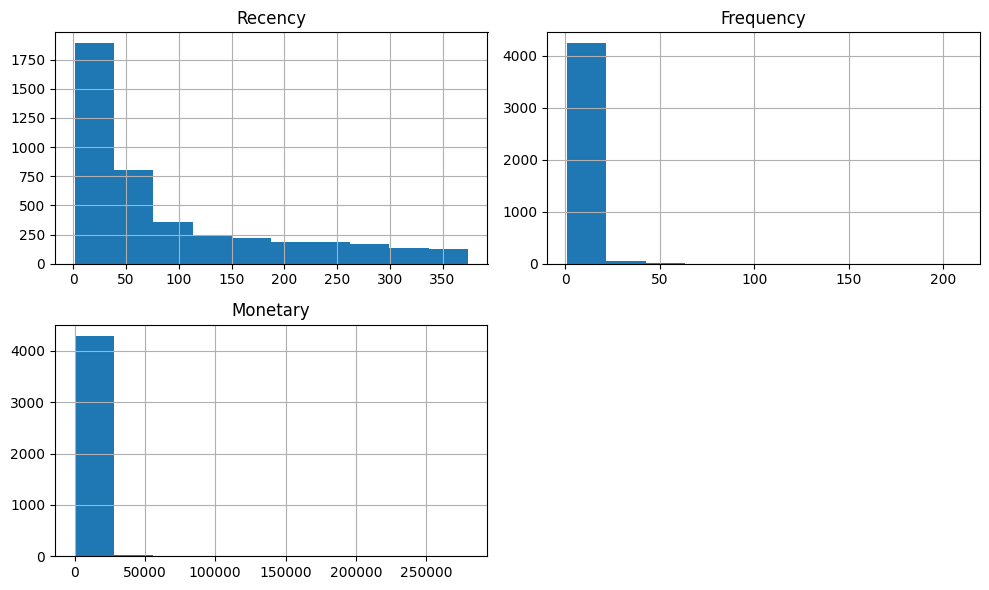

In [ ]:
import matplotlib.pyplot as plt

rfm.hist(figsize=(10, 6))
plt.tight_layout()
plt.show()

In [29]:
import numpy as np

rfm_log = np.log1p(rfm)

print(rfm_log.head())

             Recency  Frequency  Monetary
CustomerID                               
12347.0     1.098612   2.079442  8.368925
12348.0     4.330733   1.609438  7.494564
12349.0     2.995732   0.693147  7.472245
12350.0     5.739793   0.693147  5.815324
12352.0     3.610918   2.197225  7.343691


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

print(rfm_scaled)

[[-2.03557854  1.0708423   1.43140291]
 [ 0.37614082  0.38301622  0.73951409]
 [-0.62000006 -0.95792802  0.72185305]
 ...
 [-1.21582443 -0.36455074 -1.09238646]
 [-1.65441458  2.17394847  0.84185964]
 [-0.03167498  0.05645714  0.75694021]]


In [35]:
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    index=rfm.index,
    columns=["Recency", "Frequency", "Monetary"]
)

print(rfm_scaled_df.head())
print(rfm_scaled_df.describe())

             Recency  Frequency  Monetary
CustomerID                               
12347.0    -2.035579   1.070842  1.431403
12348.0     0.376141   0.383016  0.739514
12349.0    -0.620000  -0.957928  0.721853
12350.0     1.427542  -0.957928 -0.589281
12352.0    -0.160966   1.243212  0.620128
            Recency     Frequency      Monetary
count  4.322000e+03  4.322000e+03  4.322000e+03
mean   4.726539e-16  2.137218e-17 -1.315211e-17
std    1.000116e+00  1.000116e+00  1.000116e+00
min   -2.338125e+00 -9.579280e-01 -5.190991e+00
25%   -6.582737e-01 -9.579280e-01 -6.733421e-01
50%    9.297615e-02 -3.645507e-01 -6.046579e-02
75%    8.425685e-01  6.498344e-01  6.594114e-01
max    1.567176e+00  5.852903e+00  4.732577e+00


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in [2, 3, 4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=42)

    cluster_labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, cluster_labels)

    print(k, score)

2 0.43168980671659873
3 0.33495853404517795
4 0.33320395456462304
5 0.3191919736900506


In [39]:
def visualize_silhouette(cluster_lists, X_features): 
    
    from sklearn.datasets import make_blobs
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score

    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import math
    
    # 입력값으로 클러스터링 갯수들을 리스트로 받아서, 각 갯수별로 클러스터링을 적용하고 실루엣 개수를 구함
    n_cols = len(cluster_lists)
    
    # plt.subplots()으로 리스트에 기재된 클러스터링 수만큼의 sub figures를 가지는 axs 생성 
    fig, axs = plt.subplots(figsize=(4*n_cols, 4), nrows=1, ncols=n_cols)
    
    # 리스트에 기재된 클러스터링 갯수들을 차례로 iteration 수행하면서 실루엣 개수 시각화
    for ind, n_cluster in enumerate(cluster_lists):
        
        # KMeans 클러스터링 수행하고, 실루엣 스코어와 개별 데이터의 실루엣 값 계산. 
        clusterer = KMeans(n_clusters = n_cluster, max_iter=500, random_state=42)
        cluster_labels = clusterer.fit_predict(X_features)
        
        sil_avg = silhouette_score(X_features, cluster_labels)
        sil_values = silhouette_samples(X_features, cluster_labels)
        
        y_lower = 10
        axs[ind].set_title('Number of Cluster : '+ str(n_cluster)+'\n' \
                          'Silhouette Score :' + str(round(sil_avg,3)) )
        axs[ind].set_xlabel("The silhouette coefficient values")
        axs[ind].set_ylabel("Cluster label")
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])  # Clear the yaxis labels / ticks
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        
        # 클러스터링 갯수별로 fill_betweenx( )형태의 막대 그래프 표현. 
        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels==i]
            ith_cluster_sil_values.sort()
            
            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i
            
            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values, \
                                facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10
            
        axs[ind].axvline(x=sil_avg, color="red", linestyle="--")

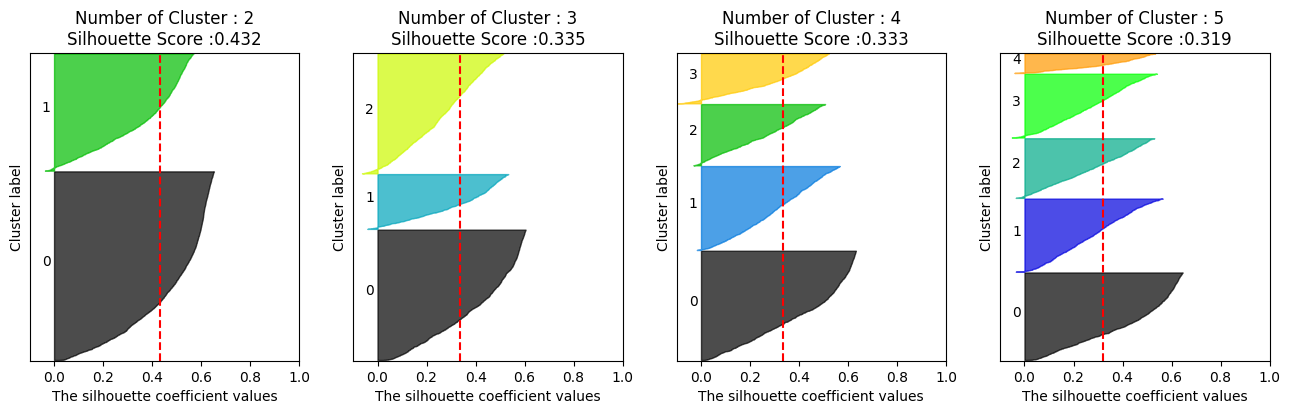

In [45]:
visualize_silhouette([2, 3, 4, 5], rfm_scaled)

In [41]:
kmeans = KMeans(n_clusters=2, random_state=42)

cluster_labels = kmeans.fit_predict(rfm_scaled)

In [43]:
rfm["Cluster"] = cluster_labels
print(rfm.head())

            Recency  Frequency  Monetary  Cluster
CustomerID                                       
12347.0           2          7   4310.00        1
12348.0          75          4   1797.24        1
12349.0          19          1   1757.55        0
12350.0         310          1    334.40        0
12352.0          36          8   1545.41        1


In [44]:
print(rfm["Cluster"].value_counts())

Cluster
0    2666
1    1656
Name: count, dtype: int64


In [46]:
cluster_mean = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

print(cluster_mean)

            Recency  Frequency     Monetary
Cluster                                    
0        133.677794   1.680045   485.270781
1         25.489734   8.474638  4225.855472


In [47]:
print(kmeans.cluster_centers_)

[[ 0.50295847 -0.60155934 -0.56105435]
 [-0.8105077   0.96940106  0.90412807]]


In [49]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

rfm_pca = pca.fit_transform(rfm_scaled)

pca_df = pd.DataFrame(
    rfm_pca,
    index=rfm.index,
    columns=["PCA1", "PCA2"]
)

pca_df["Cluster"] = cluster_labels

print(pca_df.head())

                PCA1      PCA2  Cluster
CustomerID                             
12347.0     2.557305 -0.791680        1
12348.0     0.485477  0.759354        1
12349.0     0.154824 -0.438141        0
12350.0    -1.674316  0.693800        0
12352.0     1.221301  0.468739        1


In [50]:
centers_pca = pca.transform(kmeans.cluster_centers_)

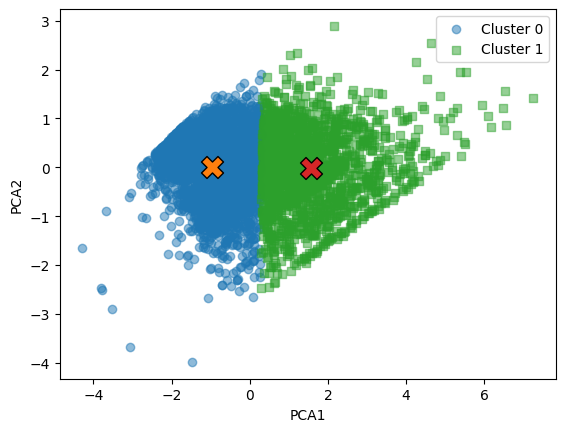

In [51]:
import matplotlib.pyplot as plt

markers = ["o", "s"]

for label in [0, 1]:
    cluster_data = pca_df[pca_df["Cluster"] == label]

    plt.scatter(
        cluster_data["PCA1"],
        cluster_data["PCA2"],
        marker=markers[label],
        alpha=0.5,
        label=f"Cluster {label}"
    )

    plt.scatter(
        centers_pca[label][0],
        centers_pca[label][1],
        s=250,
        marker="X",
        edgecolor="black"
    )

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend()
plt.show()